### Objective: Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

Tech Stack: Python, pandas, scikit-learn (KMeans), matplotlib, seaborn, Jupyter Notebook 

In [17]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [18]:
#loading the dataset
df=pd.read_csv("data\ecommerce_customer_data.csv")

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
C:\Users\bhavy\AppData\Local\Temp\ipykernel_21536\2643117384.py:2: SyntaxWarning: invalid escape sequence '\e'
  df=pd.read_csv("data\ecommerce_customer_data.csv")


In [19]:
#rows and columns in the dataset
df.shape

(250000, 13)

In [20]:
#data at a glance
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [21]:
#columns
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [23]:
df.isnull().any()

Customer ID              False
Purchase Date            False
Product Category         False
Product Price            False
Quantity                 False
Total Purchase Amount    False
Payment Method           False
Customer Age             False
Returns                   True
Customer Name            False
Age                      False
Gender                   False
Churn                    False
dtype: bool

In [24]:
#number of missing values
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [25]:
#handling missing values
df['Returns'].fillna(df['Returns'].mean, inplace=True)

#replacing all null values in the Returns column with the mean of the column

C:\Users\bhavy\AppData\Local\Temp\ipykernel_21536\2281641722.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<bound method Series.mean of 0         1.0
1         1.0
2         1.0
3         0.0
4         1.0
         ... 
249995    0.0
249996    1.0
249997    NaN
249998    1.0
249999    0.0
Name: Returns, Length: 250000, dtype: float64>' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Returns'].fillna(df['Returns'].mean, inplace=True)


In [26]:
#checking again
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

In [27]:
#checking duplicate column names
df.columns.duplicated().any()

np.False_

In [28]:
# #checking if there are duplicate values in columns
has_duplicate_values = df.T.duplicated().any()
print(has_duplicate_values)

True


In [29]:
#finding the duplicated column pair
duplicate_pairs = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            duplicate_pairs.append((df.columns[i], df.columns[j]))

print("Duplicate column pairs:")
for pair in duplicate_pairs:
    print(pair)

Duplicate column pairs:
('Customer Age', 'Age')


In [30]:
#dropping one of the duplicated column
df.drop(columns=['Age'], inplace=True)

In [31]:
df.shape

(250000, 12)

In [32]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,Female,0


# Statistical Analysis

Average purchase value

In [33]:
avg_purchase_val= df['Total Purchase Amount'].mean()
print(avg_purchase_val)

2725.385196


Purchase frequency

In [34]:
df.columns  

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Gender', 'Churn'],
      dtype='object')

In [35]:
print("Unique Customers:", df['Customer ID'].nunique())

Unique Customers: 49661


In [36]:
purchase_frequency = (df.groupby('Customer ID').size().reset_index(name='Purchase_Frequency'))
print(purchase_frequency)

       Customer ID  Purchase_Frequency
0                1                   3
1                2                   6
2                3                   4
3                4                   5
4                5                   5
...            ...                 ...
49656        49996                   7
49657        49997                   2
49658        49998                  10
49659        49999                   6
49660        50000                   7

[49661 rows x 2 columns]


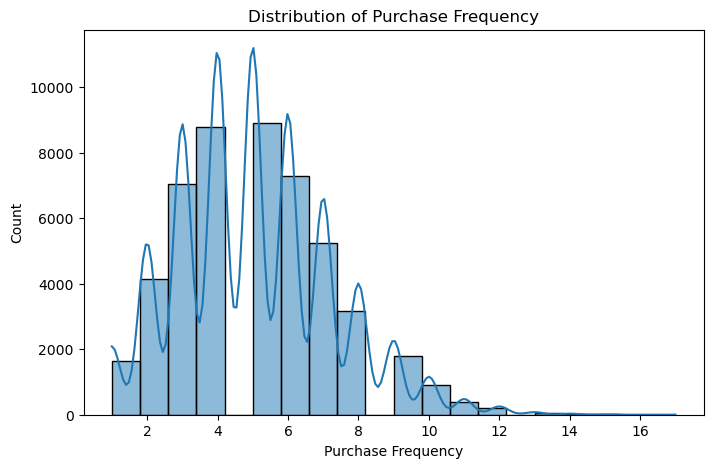

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(purchase_frequency['Purchase_Frequency'],bins=20,kde=True)

plt.title("Distribution of Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.savefig('images/Purchase_frequency.png')
plt.show()

In [38]:
purchase_frequency.sort_values(by='Purchase_Frequency', ascending=False).head(10)

,Customer ID,Purchase_Frequency
48056,48382,17
4179,4200,16
8720,8770,16
25765,25927,15
42837,43126,15
35064,35294,15
46844,47165,15
12568,12647,15
39625,39895,15
32656,32869,15


In [39]:
purchase_frequency.nlargest(1, 'Purchase_Frequency')

,Customer ID,Purchase_Frequency
48056,48382,17


Customer with ID=48382 has the highest purchase frquency of 17

Customer lifetime value

In [40]:
clv = df.groupby('Customer ID')['Total Purchase Amount'].sum().reset_index(name=('Customer_Lifetime_Value'))
print(clv.head())
print(" ")
print(clv.nlargest(1,'Customer_Lifetime_Value'))

   Customer ID  Customer_Lifetime_Value
0            1                     6290
1            2                    16481
2            3                     9423
3            4                     7826
4            5                     9769
 
       Customer ID  Customer_Lifetime_Value
39625        39895                    50659


Customer with ID= 39895 has the highest customer lifetime value

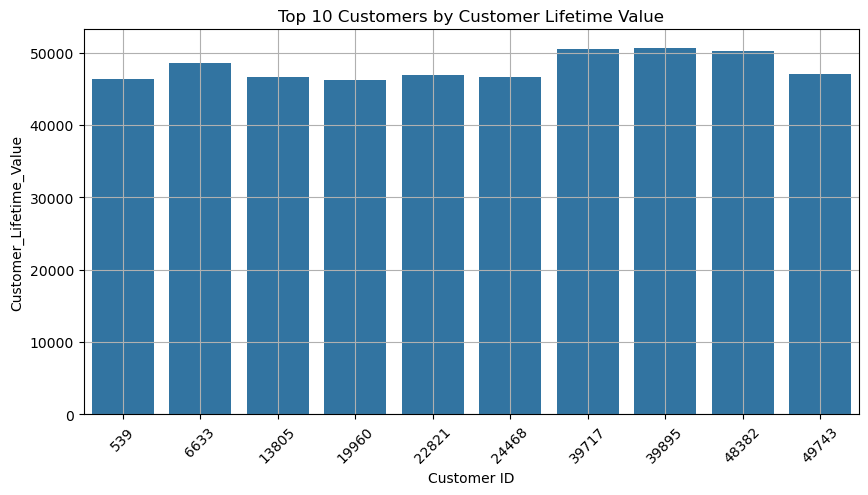

In [41]:
top10 = clv.nlargest(10, 'Customer_Lifetime_Value')

plt.figure(figsize=(10,5))
sns.barplot(data=top10,x='Customer ID',y='Customer_Lifetime_Value')

plt.title("Top 10 Customers by Customer Lifetime Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig('images/CLV.png')
plt.show()

# RFM (Recency, Frequency, Monetary Analysis)

In [42]:
#changing the data type of the Purchase date column
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
print(df['Purchase Date'].dtype)

datetime64[ns]


Recency

In [43]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Gender', 'Churn'],
      dtype='object')

In [44]:
reference_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

In [45]:
recency=df.groupby('Customer ID')['Purchase Date'].max().reset_index()
recency['Recency'] = (reference_date - recency['Purchase Date']).dt.days

recency = recency[['Customer ID','Recency']]
recency.head()

,Customer ID,Recency
0,1,289
1,2,73
2,3,223
3,4,442
4,5,425


In [46]:
recency.sort_values(by='Recency',ascending=False).head(10)

,Customer ID,Recency
10406,10472,1352
40195,40467,1351
7860,7909,1351
40074,40346,1350
40274,40546,1348
39067,39332,1348
10399,10465,1347
20994,21131,1346
46152,46465,1344
17026,17139,1343


Customer with Customer ID 10742 has highest recency

In [47]:
recency.sort_values(by='Recency',ascending=True).head(10)

,Customer ID,Recency
21870,22010,1
45943,46253,1
43789,44085,1
21477,21616,1
30672,30869,1
25271,25432,1
20120,20249,1
11033,11104,1
36113,36351,1
7933,7982,1


Customer with Customer ID = 22010 is the most recent customer i.e has made a purchase recently

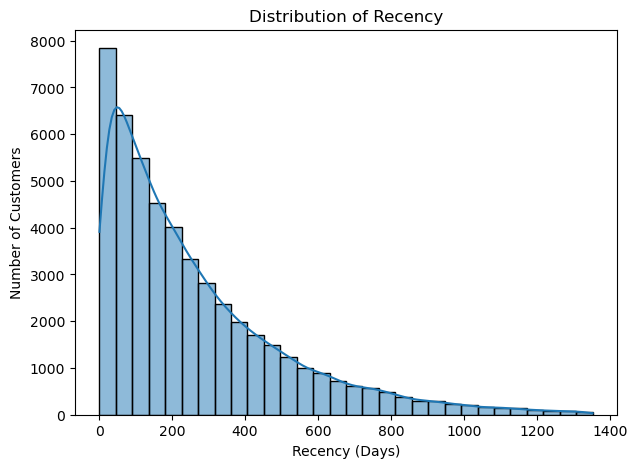

In [48]:
plt.figure(figsize=(7,5))
sns.histplot(recency['Recency'], bins=30, kde=True)

plt.title("Distribution of Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")
plt.savefig('images/recency.png')
plt.show()

From the graph it is clear that the recency has decreased over the days

Frequency

In [49]:
frequency = df.groupby('Customer ID').size().reset_index(name='Frequency')
frequency.sort_values(by='Frequency', ascending=False).head(1)

,Customer ID,Frequency
48056,48382,17


Customer with ID=48382 has the highest purchase frquency of 17

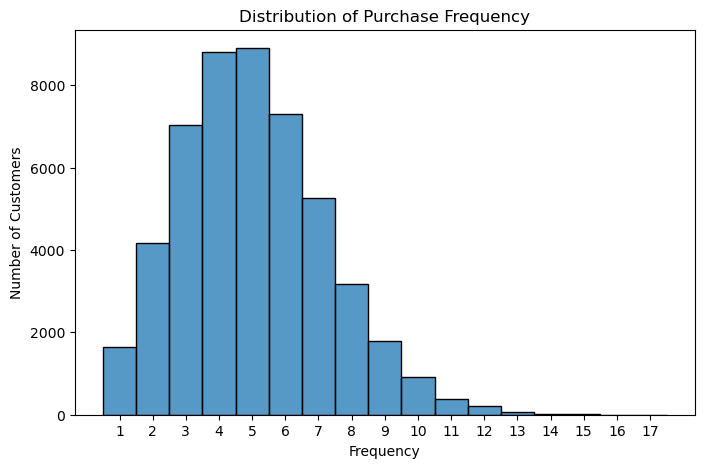

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(frequency['Frequency'], discrete=True)

plt.title("Distribution of Purchase Frequency")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.xticks(range(1, frequency['Frequency'].max() + 1))
plt.savefig('images/pur_frq_distribution.png')
plt.show()

The maximum purchase frequency observed was 17 purchases. However, the majority of customers made between 1 and 5 purchases, indicating that repeat purchases beyond five transactions are relatively uncommon.

Monetary

In [51]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Gender', 'Churn'],
      dtype='object')

In [52]:
monetary=df.groupby('Customer ID')['Total Purchase Amount'].sum().reset_index(name='Monetary')
monetary.sort_values(by='Monetary', ascending=False).head(1)

,Customer ID,Monetary
39625,39895,50659


Customer with ID = 39895 has the highest contribution to Total amount 

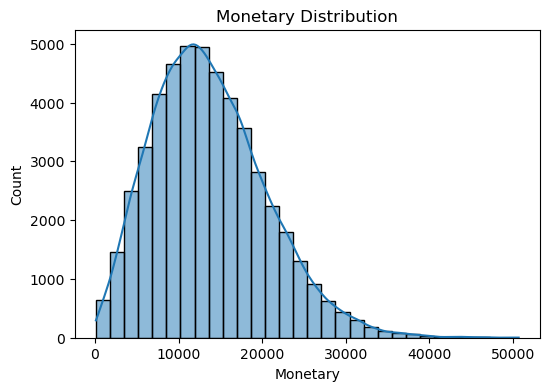

In [53]:
plt.figure(figsize=(6,4))
sns.histplot(monetary['Monetary'],bins=30,kde=True)
plt.title("Monetary Distribution")
plt.savefig('images/monetary_distribution.png')
plt.show()

The maximum amount observed was 50659. However, the majority of customers made sales between 10,000 and 25,000, indicating that repeat sales beyond 25,000 is relatively uncommon."


Merging all of RFM

In [54]:
rfm = recency.merge(frequency,on='Customer ID')
rfm = rfm.merge(monetary,on='Customer ID')
rfm.tail(10)


,Customer ID,Recency,Frequency,Monetary
49651,49991,144,7,19723
49652,49992,30,5,16512
49653,49993,66,5,11942
49654,49994,97,7,21725
49655,49995,32,6,21746
49656,49996,360,7,24034
49657,49997,389,2,5714
49658,49998,14,10,20495
49659,49999,357,6,14321
49660,50000,123,7,21927


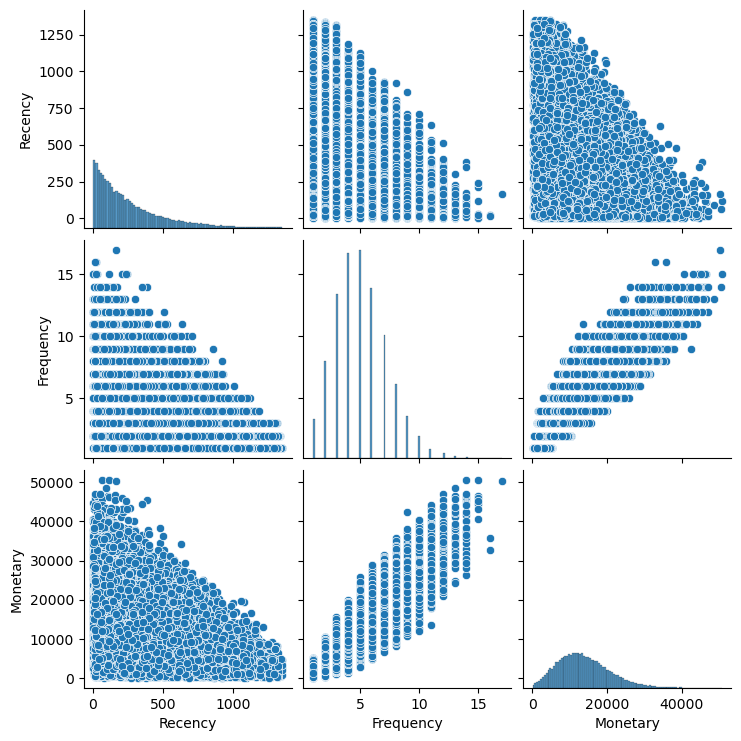

In [55]:
sns.pairplot(rfm[['Recency','Frequency','Monetary']])
plt.savefig('images/rfm_pairplot.png')
plt.show()

# Standardisation

In [56]:
rfm.columns

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary'], dtype='object')

In [57]:
rfm_features = rfm[['Recency','Frequency','Monetary']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

Standardization puts all three features on the same scale so that Recency, Frequency, and Monetary contribute equally to the clustering

In [58]:
#converting back to dataframe 
rfm_scaled = pd.DataFrame(rfm_scaled,columns=rfm_features.columns)
rfm_scaled.head()

,Recency,Frequency,Monetary
0,0.108041,-0.924867,-1.090875
1,-0.767155,0.439156,0.405382
2,-0.159380,-0.470193,-0.630884
3,0.727971,-0.015519,-0.865357
4,0.659089,-0.015519,-0.580084


In [59]:
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,49661.00,49661.00,49661.00
mean,0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.06,-1.83,-2.00
25%,-0.75,-0.92,-0.73
50%,-0.31,-0.02,-0.10
75%,0.44,0.44,0.62
max,4.42,5.44,5.42


Applying elbow method on this scaled data

In [64]:
wcss = []
cluster_centre=[]
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
    cluster_centre.append(kmeans.cluster_centers_)

In [65]:
cluster_centre

[array([[6.96032775e-17, 6.53198613e-17, 2.00354780e-17]]),
 array([[ 0.38234416, -0.70348878, -0.69629754],
        [-0.45455611,  0.83635415,  0.82780473]]),
 array([[-0.42469963,  1.09321191,  1.09746802],
        [-0.33006873, -0.39175956, -0.42480199],
        [ 1.70239074, -0.95915295, -0.87598281]]),
 array([[ 1.86806374, -0.9603079 , -0.86929674],
        [-0.49256728,  1.55356598,  1.57837911],
        [-0.26026561, -0.75592807, -0.78187123],
        [-0.32940176,  0.31523992,  0.28830495]]),
 array([[-0.3321108 , -0.80400345, -0.83515273],
        [-0.5633915 ,  0.35370758,  0.30535246],
        [ 2.1059197 , -1.22618238, -1.13110743],
        [-0.48139448,  1.58642835,  1.6165843 ],
        [ 0.83935468, -0.09426598, -0.0325688 ]]),
 array([[ 0.89400965, -0.1160836 , -0.05285648],
        [-0.48276579,  0.80231792,  0.78655222],
        [-0.14896028, -1.02605596, -1.03358647],
        [-0.57118746, -0.10531919, -0.1681535 ],
        [-0.51877507,  1.93672754,  1.97629438],
 

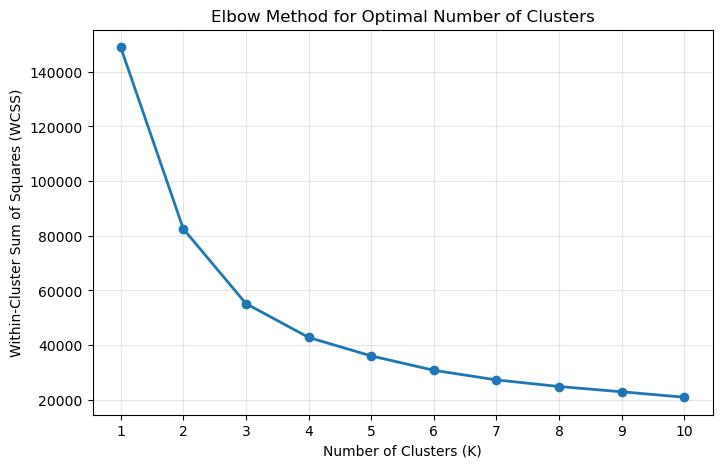

In [61]:
plt.figure(figsize=(8,5))

plt.plot(range(1, 11), wcss, marker='o', linewidth=2)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")

plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.savefig('images/elbow_method.png')
plt.show()

The Elbow Method was used to determine the optimal number of clusters. The Within-Cluster Sum of Squares (WCSS) decreases as the number of clusters increases. The point where the reduction in WCSS begins to level off (the "elbow") was selected as the optimal value of K for K-Means clustering.

Here, The optimal value of k is taken as 3 

# Plottig

In [63]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Gender', 'Churn'],
      dtype='object')

In [70]:
#adding cluster labels
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,1,289,3,6290,1
1,2,73,6,16481,0
2,3,223,4,9423,1
3,4,442,5,7826,1
4,5,425,5,9769,1


Scatter plot between frequency and monetary

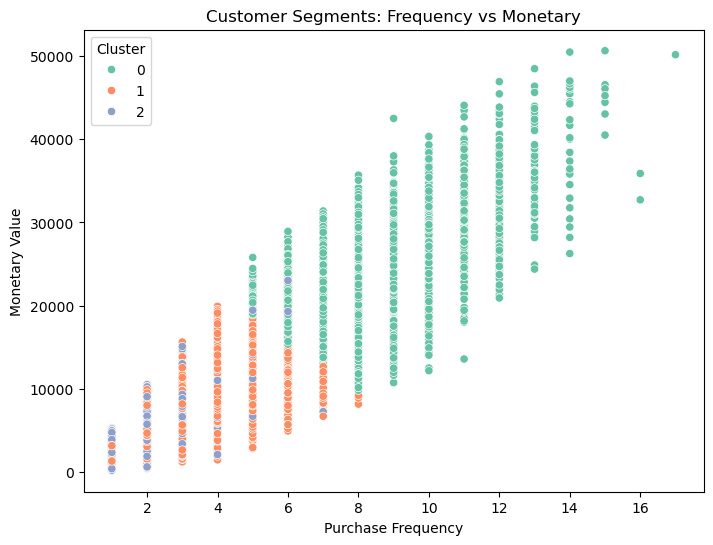

In [73]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=rfm,x='Frequency',y='Monetary',hue='Cluster',palette='Set2',)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.savefig('images/freq_vs_monetary.png')
plt.show()

- Top-right → Loyal high-value customers
- Bottom-left → Low-value customers
- Other regions → Medium-value segments

Scatter plot between recency and monetary

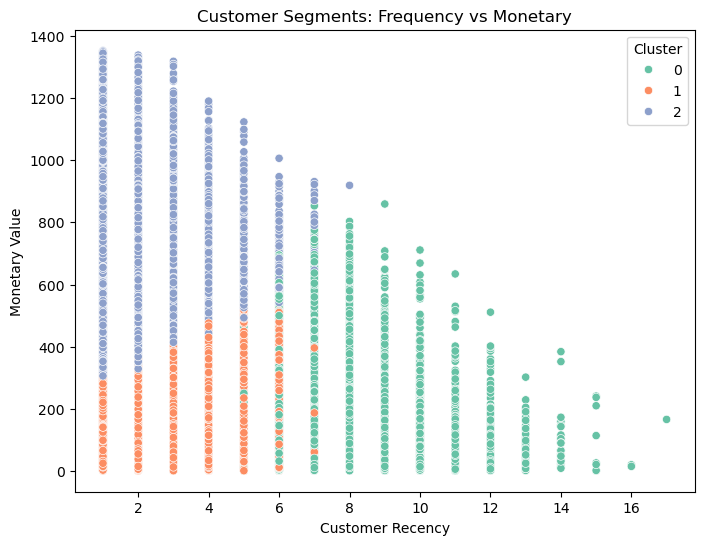

In [76]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=rfm,x='Frequency',y='Recency',hue='Cluster',palette='Set2',)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Customer Recency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.savefig('images/recency_vs_monetary.png')
plt.show()

- Low Recency + High Monetary → Recent high spenders (excellent customers)
- High Recency + Low Monetary → Dormant customers

Customer profile

In [78]:
cluster_profile = (rfm.groupby('Cluster').agg({'Recency': 'mean','Frequency': 'mean','Monetary': 'mean'}).round(2))

print(cluster_profile)

         Recency  Frequency  Monetary
Cluster                              
0         157.55       7.44  21200.70
1         181.04       4.18  10834.42
2         682.54       2.92   7738.39


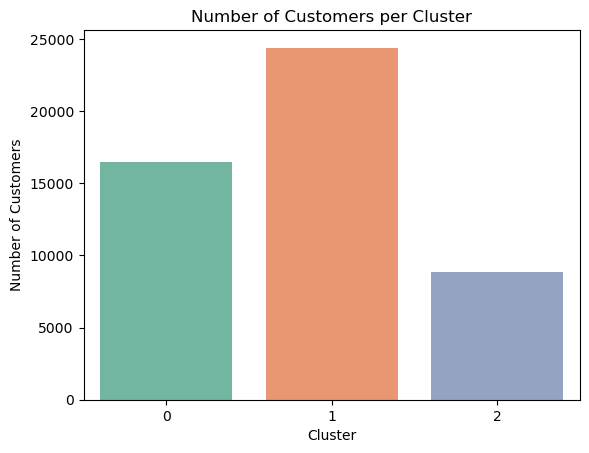

In [80]:
sns.countplot(data=rfm, x='Cluster', hue='Cluster', palette='Set2',legend=False)
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.savefig('images/Customer_per_cluster.png')
plt.show()

| Cluster | Customer Type        | Characteristics                                     | Marketing Action                                             |
| ------: | -------------------- | --------------------------------------------------- | ------------------------------------------------------------ |
|       0 | VIP Customers        | Recent purchases, frequent buyers, highest spending | Reward with loyalty programs, exclusive offers, early access |
|       2 | At-Risk Customers    | Inactive, infrequent purchases, low spending        | Win-back campaigns, personalized discounts, reminder emails  |
|       1 | Potential Loyalists  | Moderate activity and spending                      | Cross-selling, personalized recommendations, reward points   |
